#### Question Statement

## Q.6 Principle Component Analysis 
Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).

Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

Importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO
import seaborn as sns

In [2]:
df_filtered   = pd.read_csv(
    "data/PCA/filtered.tsv.gz",
    sep="\t",
    compression="gzip"
)
df_classes    = pd.read_csv(
    "data/PCA/class.tsv",
    sep="\t",
    header=None
)
df_columns    = pd.read_csv(
    "data/PCA/columns.tsv.gz",
    sep="\t",
    comment="#",
    compression="gzip"
)

# get the raw numeric IDs
gata3_id      = df_columns.loc[df_columns['GeneSymbol']=="GATA3", 'ID'].values[0]
xbp1_id       = df_columns.loc[df_columns['GeneSymbol']=="XBP1",  'ID'].values[0]

# convert to the string format used as column keys
gata3_id      = " " + str(gata3_id)
xbp1_id       = " " + str(xbp1_id)

# pull out the expression arrays and class labels
expr_gata3    = df_filtered[gata3_id].values
expr_xbp1     = df_filtered[xbp1_id].values
class_labels  = df_classes[0].values

print(f"GATA3 ID: {gata3_id} , XBP1 ID: {xbp1_id}")


GATA3 ID:  4359 , XBP1 ID:  4404


Principal Component Analysis (PCA) is an unsupervised approach that compresses high‑dimensional data into a few key axes while retaining the bulk of its variability—an ideal fit for gene expression studies. In our breast cancer cohort, projecting samples onto the first two principal components cleanly separates ER‑positive from ER‑negative cases. Genes like XBP1 and GATA3 stand out as strong subtype markers, and the first component alone accounts for most of the variance, underscoring its power to distinguish these cancer types.


## Scatter plot of GATA3 vs XBP1 by ER status

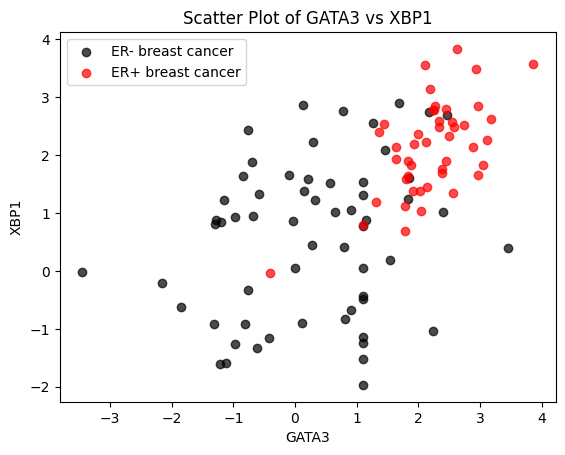

In [3]:

plt.scatter(
    expr_gata3[class_labels == 0],
    expr_xbp1[class_labels == 0],
    color='black',
    alpha=0.7,
    label='ER- breast cancer'
)
plt.scatter(
    expr_gata3[class_labels == 1],
    expr_xbp1[class_labels == 1],
    color='red',
    alpha=0.7,
    label='ER+ breast cancer'
)

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1")
plt.legend()
plt.show()


#### PCA computation and plotting

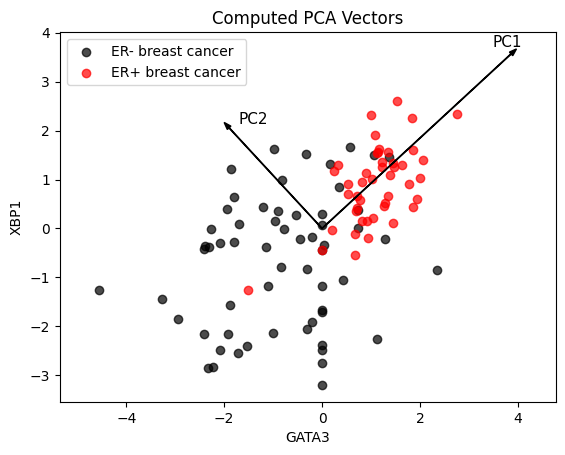

In [4]:


data_matrix    = np.vstack((expr_gata3, expr_xbp1)).T

# Center the data
data_mean      = np.mean(data_matrix, axis=0)
data_centered  = data_matrix - data_mean

# Compute covariance matrix
cov_matrix     = np.cov(data_centered.T)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
sorted_idx     = np.argsort(eigenvalues)[::-1]
eigenvalues    = eigenvalues[sorted_idx]
eigenvectors   = eigenvectors[:, sorted_idx]

# scatter by class
plt.scatter(
    data_centered[class_labels == 0, 0],
    data_centered[class_labels == 0, 1],
    color='black', alpha=0.7, label='ER- breast cancer'
)
plt.scatter(
    data_centered[class_labels == 1, 0],
    data_centered[class_labels == 1, 1],
    color='red',   alpha=0.7, label='ER+ breast cancer'
)

# Plot principal component vectors
origin = np.array([0, 0])
for i in range(2):
    vector_end = np.sqrt(eigenvalues[i]) * eigenvectors.T[i] * 3
    plt.arrow(
        origin[0], origin[1],
        vector_end[0], vector_end[1],
        color='black', width=0.01, head_width=0.1
    )
    plt.text(
        vector_end[0] * 0.9,
        vector_end[1] * 1.04,
        f'PC{i+1}', fontsize=11
    )

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Computed PCA Vectors")
plt.legend()
plt.axis('equal')
plt.show()


#### PC1 projection and DataFrame assembly

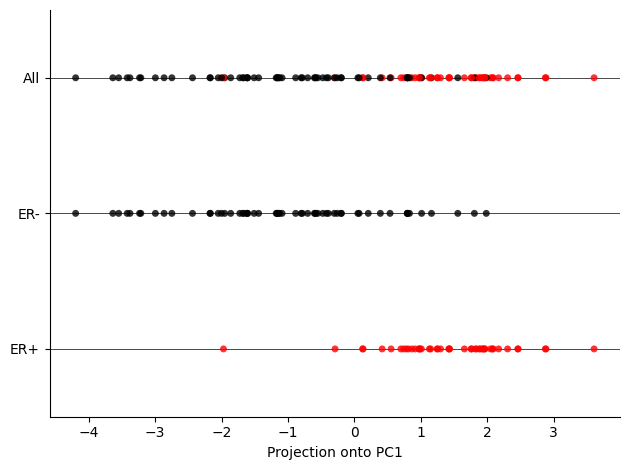

In [5]:

# project onto PC1
pc1_projection = data_centered @ eigenvectors[:, 0]

# assemble a DataFrame for all samples
df_pc1_all = pd.DataFrame({
    "PC1":   pc1_projection,
    "Group": "All",
    "Color": np.where(class_labels == 0, "black", "red")
})

# split by ER status
df_pc1_er_minus = pd.DataFrame({
    "PC1":   pc1_projection[class_labels == 0],
    "Group": "ER-",
    "Color": "black"
})
df_pc1_er_plus  = pd.DataFrame({
    "PC1":   pc1_projection[class_labels == 1],
    "Group": "ER+",
    "Color": "red"
})

# combine for plotting
df_pc1_combined = pd.concat(
    [df_pc1_all, df_pc1_er_minus, df_pc1_er_plus],
    ignore_index=True
)

ax = sns.stripplot(
    data=df_pc1_combined,
    x="PC1",
    y="Group",
    hue="Color",
    palette={"black": "black", "red": "red"},
    dodge=False,
    jitter=False,
    alpha=0.8,
    size=5
)
ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


#### Variance explained and scree plot

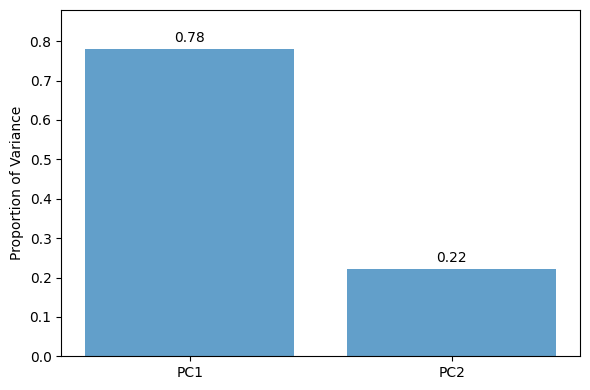

In [6]:

variance_ratio   = eigenvalues / np.sum(eigenvalues)

plt.figure(figsize=(6, 4))
pca_components   = [f"PC{i+1}" for i in range(len(variance_ratio))]
plt.bar(pca_components, variance_ratio, alpha=0.7)
for i, v in enumerate(variance_ratio):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')

plt.ylabel('Proportion of Variance')
plt.ylim(0, max(variance_ratio) + 0.1)
plt.tight_layout()
plt.show()
